## Cross-validation

Used to estimate how accurately a predictive model will perform in practice.

In [8]:
import sys
print(sys.executable)

# general python modules for scientific analysis
import sys, pathlib, os, itertools, os
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

sys.path.append('../../src')
from sklearn.model_selection import train_test_split
from physion.analysis.read_NWB import Data
from physion.analysis.dataframe import NWB_to_dataframe, extract_stim_keys
from physion.utils import plot_tools as pt

sys.path.append('../../src/physion/analysis')
from cross_validation import TwoFold_train_test_split

C:\Users\laura.gonzalez\AppData\Local\miniforge3\python.exe


In [9]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','NDNF-WT-Dec-2022','NWBs')
filename = os.path.join(datafolder, '2022_12_14-13-27-41.nwb') #for example
data = Data(filename)
df = NWB_to_dataframe(filename,
                      normalize=['dFoF', 'Pupil-diameter', 'Running-Speed', 'Whisking'],
                      visual_stim_label='per-protocol-and-parameters',
                      verbose=False)

NWB-file reading time: 903.8ms


In [51]:
from physion.analysis.process_NWB import EpisodeData

def compute_high_movement_cond(behav_episodes,
                               running_speed_threshold):
    # HMcond: high movement condition
    if running_speed_threshold is not None:
        HMcond = (behav_episodes.running_speed.mean(axis=1)>running_speed_threshold) 
    return HMcond

behav_episodes = EpisodeData(data, 
                             quantities=['Pupil', 'Running-Speed'],
                             #protocol_name=protocol,
                             prestim_duration=0,
                             verbose=False)
        
# HMcond: high movement condition
HMcond = compute_high_movement_cond(behav_episodes, running_speed_threshold=0.1)
ax.plot(behav_episodes.pupil_diameter.mean(axis=1)[~HMcond],
                behav_episodes.running_speed.mean(axis=1)[~HMcond], 'o', color='tab:blue')
ax.plot(behav_episodes.pupil_diameter.mean(axis=1)[HMcond],
                behav_episodes.running_speed.mean(axis=1)[HMcond], 'o', color='tab:orange')

protocols: ['moving-dots' 'random-dots' 'static-patch' 'looming-stim'
 'Natural-Images-4-repeats' 'grey-10min' 'drifting-gratings']
 [!!] need to explicit the "protocol_id" or "protocol_name" [!!] 
         ---->   set to protocol_id=0 by default 
 
 [!!] need to pass either a protocol_id or a protocol_name [!!] 



{'spont_train_sets': [array([ 9619,  9620,  9621, ..., 18443, 18444, 18445]), array([18446, 18447, 18448, ..., 27270, 27271, 27272])], 'spont_test_sets': [array([18446, 18447, 18448, ..., 27270, 27271, 27272]), array([ 9619,  9620,  9621, ..., 18443, 18444, 18445])], 'stim_train_sets': [array([    0,     1,     2, ..., 38605, 38606, 38607]), array([38608, 38609, 38610, ..., 59559, 59560, 59561])], 'stim_test_sets': [array([38608, 38609, 38610, ..., 59559, 59560, 59561]), array([    0,     1,     2, ..., 38605, 38606, 38607])]}

calculating dF/F with method "percentile" [...]

  ** all ROIs passed the positive F0 criterion ** 

-> dFoF calculus done !  (calculation took 0.0s)
eeeh 59562


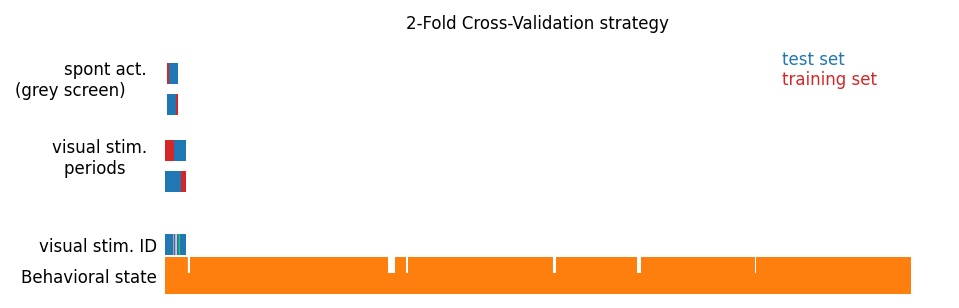

In [114]:
cvIndices = TwoFold_train_test_split(df, spont_act_key='VisStim_grey-10min')
print(cvIndices)

# Plot
fig, ax = plt.subplots(figsize=(7,2))
ii = 13

#spontaneous
for train, test in zip(cvIndices['spont_train_sets'], cvIndices['spont_test_sets']):
    ax.scatter(df['time'][train], ii+0.5+np.zeros(len(df['time'][train])), c='tab:red', marker="_", lw=10)
    ax.scatter(df['time'][test], ii+0.5+np.zeros(len(df['time'][test])), c='tab:blue', marker="_", lw=10)
    ii-=2
ax.annotate('spont act.    \n(grey screen)        ', (0, ii+3), ha='right')
ii-=1

#evoked
for train, test in zip(cvIndices['stim_train_sets'], cvIndices['stim_test_sets']):
    
    ax.scatter(df['time'][train], ii+0.5+np.zeros(len(df['time'][train])), c='tab:red', marker="_", lw=10)
    ax.scatter(df['time'][test], ii+0.5+np.zeros(len(df['time'][test])), c='tab:blue', marker="_", lw=10)
    ii-=2
ax.annotate('visual stim.    \nperiods        ', (0, ii+3), ha='right')
ii-=1

#stim id
stim_keys = [k for k in df if ('VisStim' in k)]
stimID = 0*df['time']
stim_cond = (~df['VisStim_grey-10min'])
for i, k in enumerate(stim_keys):
        stimID[df[k]] = i+1
ax.scatter(df['time'][stim_cond], [ii-0.5] * np.sum(stim_cond), c=stimID[stim_cond], marker="_", lw=10, cmap=plt.cm.tab20)
ax.annotate('visual stim. ID  ', (0, ii-1), ha='right')
ii-=1


#movement
data.build_dFoF()
print("eeeh", len(data.t_dFoF))
running_dFoF_sampled = data.build_running_speed(specific_time_sampling=data.t_)
speed_bool = []
for speed in running_dFoF_sampled:
    if speed >= 0.1:
        speed_bool.append(True)
    else: 
        speed_bool.append(False)
ax.scatter(np.arange(len(speed_bool)), speed_bool, c='tab:orange', marker="_", lw=10, label="Above Threshold")
#ax.scatter(np.arange(len(x)), speed_bool, c='tab:blue', marker="_", lw=10, label="Below Threshold")


ax.annotate('Behavioral state  ', (0, ii-2), ha='right')
ii-=1

#print("bb", x_above)
#x_below = df['Running-Speed'][df['Running-Speed'] < 0.1]   # Values below threshold
#print(behav_episodes.running_speed.mean(axis=1))
#x = df['time']
#y = np.zeros(len(df['time']))
#ax.scatter(x, y, c='tab:red', marker="_", lw=10)
#ii-=1
#x_ = df['time']
#y_ = np.zeros(len(df['time']))
#ax.scatter(x_, y_, c='tab:blue', marker="_", lw=10)

#print("aa", df['Running-Speed'])
#x_above = df['Running-Speed'][df['Running-Speed'] >= 0.1]  # Values above threshold

ax.annotate('training set', (.8,.9), color='tab:red', xycoords='axes fraction')
ax.annotate('test set\n', (.8,.9), color='tab:blue', xycoords='axes fraction')

ax.axis('off')
ax.set_xlabel("time (s)")
ax.set_title('2-Fold Cross-Validation strategy\n ')
ax.axes.get_xaxis().set_visible(True)

To do: 
- Have the same number of episodes in training and test sets
- Have the same proportion of active vs quiet state in training and tests sets
- Shuffle visual stimulation
  